In [1]:
import tensorflow as tf
import keras
import numpy as np
import sys

sys.path.append("../")

In [2]:
DATA_DIR = "../mu3e_trigger_data"
SIGNAL_PIXEL_FILE = f"{DATA_DIR}/run42_sig_pixel_128.npy"
BACKGROUND_PIXEL_FILE = f"{DATA_DIR}/run42_bg_pixel_128.npy"
SIGNAL_DATA_FILE = f"{DATA_DIR}/run42_sig_mppc_128.npy"
BACKGROUND_DATA_FILE = f"{DATA_DIR}/run42_bg_mppc_128.npy"

bg_pixel_spacetime = np.load(BACKGROUND_PIXEL_FILE)
sig_pixel_spacetime = np.load(SIGNAL_PIXEL_FILE)
bg_mppc_spacetime = np.load(BACKGROUND_DATA_FILE)
sig_mppc_spacetime = np.load(SIGNAL_DATA_FILE)

input_seq_len = bg_pixel_spacetime.shape[1]
input_dim = bg_pixel_spacetime.shape[2] - 1  # Exclude timestamp

In [ ]:
pixel_space_input = keras.Input(shape=(128, 3), name="pixel_input")
mppc_space_input = keras.Input(shape=(128, 2), name="mppc_input")
pixel_time_input = keras.Input(shape=(128, 1), name="pixel_time_input")
mppc_time_input = keras.Input(shape=(128, 1), name="mppc_time_input")

In [ ]:
from src.model.components import (
    point_transformer,
    SelfAttentionStack,
    MultiHeadAttentionBlock,
    MLP,
    GenerateMask,
    PoolingAttentionBlock,
)


pixel_mask = GenerateMask(-1, name="pixel_mask")(pixel_space_input)
mppc_mask = GenerateMask(-1, name="mppc_mask")(mppc_space_input)

pixel_point_transformer = point_transformer(name="pixel_point_transformer")(
    pixel_time_input, pixel_space_input, mask=pixel_mask
)

mppc_point_transformer = point_transformer()(
    mppc_time_input, mppc_space_input, mask=mppc_mask
)
pixel_attention = SelfAttentionStack(4, 8, 3, name="pixel_attention")(
    pixel_point_transformer, pixel_mask
)

mppc_attention = SelfAttentionStack(4, 8, 3, name="mppc_attention")(
    mppc_point_transformer, mppc_mask
)

pixel_attend_mppc = MultiHeadAttentionBlock(
    key_dim=8, num_heads=4, name="mppc_attend_pixel"
)(pixel_attention, mppc_attention, query_mask=pixel_mask, value_mask=mppc_mask)

mppc_attend_pixel = MultiHeadAttentionBlock(
    key_dim=8, num_heads=4, name="pixel_attend_mppc"
)(mppc_attention, pixel_attention, query_mask=mppc_mask, value_mask=pixel_mask)


mppc_attend_pixel_mlp = MLP(
    num_layers=3, output_dim=8, name="pixel_attend_mppc_mlp", activation="relu"
)(mppc_attend_pixel)
pixel_attend_mppc_mlp = MLP(
    num_layers=3, output_dim=8, name="mppc_attend_pixel_mlp", activation="relu"
)(pixel_attend_mppc)

pixel_attention_pool = PoolingAttentionBlock(
    key_dim=8, num_heads=4, num_seeds=1, name="pixel_attention_pool"
)(mppc_attend_pixel_mlp, mask=pixel_mask)

mppc_attention_pool = PoolingAttentionBlock(
    key_dim=8, num_heads=4, num_seeds=1, name="mppc_attention_pool"
)(pixel_attend_mppc_mlp, mask=mppc_mask)


pixel_attention_pool = keras.layers.Flatten(name="pixel_attention_flatten")(
    pixel_attention_pool
)
mppc_attention_pool = keras.layers.Flatten(name="mppc_attention_flatten")(
    mppc_attention_pool
)

latent_space = keras.layers.Concatenate(name="latent_space")(
    [pixel_attention_pool, mppc_attention_pool]
)

output = MLP(
    num_layers=5,
    output_dim=1,
    name="output_mlp",
    activation="sigmoid",
)(latent_space)

model = keras.Model(
    inputs=[pixel_space_input, mppc_space_input, pixel_time_input, mppc_time_input],
    outputs=output,
    name="mu3e_trigger_classification_model",
)
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss=keras.losses.BinaryCrossentropy(),
    metrics=[keras.metrics.BinaryAccuracy(name="accuracy")],
)
model.summary()

Model: "mu3e_trigger_classification_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ mppc_input          │ (None, 128, 2)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pixel_input         │ (None, 128, 3)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mppc_time_input     │ (None, 128, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mppc_mask           │ (None, 128, 1)    │          0 │ mppc_input[0][0]  │
│ (GenerateMask)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pixel_time_input    │ (None, 128, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pixel_mask          │ (None, 128, 1)    │          0 │ pixel_input[0][0] │
│ (GenerateMask)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ point_transformer   │ (None, 128, 8)    │        476 │ mppc_time_input[… │
│ (point_transformer) │                   │            │ mppc_input[0][0], │
│                     │                   │            │ mppc_mask[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pixel_point_transf… │ (None, 128, 8)    │        484 │ pixel_time_input… │
│ (point_transformer) │                   │            │ pixel_input[0][0… │
│                     │                   │            │ pixel_mask[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mppc_attention      │ (None, 128, 8)    │      4,320 │ point_transforme… │
│ (SelfAttentionStac… │                   │            │ mppc_mask[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pixel_attention     │ (None, 128, 8)    │      4,320 │ pixel_point_tran… │
│ (SelfAttentionStac… │                   │            │ pixel_mask[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pixel_attend_mppc   │ (None, 128, 8)    │      1,440 │ mppc_attention[0… │
│ (MultiHeadAttentio… │                   │            │ pixel_attention[… │
│                     │                   │            │ mppc_mask[0][0],  │
│                     │                   │            │ pixel_mask[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mppc_attend_pixel   │ (None, 128, 8)    │      1,440 │ pixel_attention[… │
│ (MultiHeadAttentio… │                   │            │ mppc_attention[0… │
│                     │                   │            │ pixel_mask[0][0], │
│                     │                   │            │ mppc_mask[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pixel_attend_mppc_… │ (None, 128, 8)    │        432 │ pixel_attend_mpp… │
│ (MLP)               │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mppc_attend_pixel_… │ (None, 128, 8)    │        432 │ mppc_attend_pixe… │
│ (MLP)               │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pixel_attention_po… │ (None, 1, 8)      │      1,448 │ pixel_attend_mpp

 Total params: 16,323 (63.76 KB)

 Trainable params: 16,323 (63.76 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from sklearn.model_selection import train_test_split

(
    X_pixel_space_train,
    X_pixel_space_test,
    X_mppc_space_train,
    X_mppc_space_test,
    X_pixel_time_train,
    X_pixel_time_test,
    X_mppc_time_train,
    X_mppc_time_test,
    y_train,
    y_test,
) = train_test_split(
    np.concatenate(
        [bg_pixel_spacetime[:, :, :-1], sig_pixel_spacetime[:, :, :-1]], axis=0
    ),
    np.concatenate(
        [bg_mppc_spacetime[:, :, :-1], sig_mppc_spacetime[:, :, :-1]], axis=0
    ),
    np.concatenate(
        [bg_pixel_spacetime[:, :, -1:], sig_pixel_spacetime[:, :, -1:]], axis=0
    ),
    np.concatenate(
        [bg_mppc_spacetime[:, :, -1:], sig_mppc_spacetime[:, :, -1:]], axis=0
    ),
    np.concatenate(
        [np.zeros(len(bg_pixel_spacetime)), np.ones(len(sig_pixel_spacetime))]
    ),
    test_size=0.2,
    random_state=42,
)

In [6]:
model.fit(
    x=[X_pixel_space_train, X_mppc_space_train, X_pixel_time_train, X_mppc_time_train],
    y=y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=512,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=4, restore_best_weights=True
        )
    ],
)

Epoch 1/10
174/174 ━━━━━━━━━━━━━━━━━━━━ 574s 3s/step - accuracy: 0.5592 - loss: 0.6816 - val_accuracy: 0.5773 - val_loss: 0.6722
Epoch 2/10
174/174 ━━━━━━━━━━━━━━━━━━━━ 534s 3s/step - accuracy: 0.5916 - loss: 0.6691 - val_accuracy: 0.5944 - val_loss: 0.6640
Epoch 3/10
174/174 ━━━━━━━━━━━━━━━━━━━━ 554s 3s/step - accuracy: 0.5944 - loss: 0.6642 - val_accuracy: 0.6166 - val_loss: 0.6542
Epoch 4/10
174/174 ━━━━━━━━━━━━━━━━━━━━ 1921s 11s/step - accuracy: 0.6034 - loss: 0.6591 - val_accuracy: 0.6058 - val_loss: 0.6548
Epoch 5/10
174/174 ━━━━━━━━━━━━━━━━━━━━ 2221s 7s/step - accuracy: 0.6123 - loss: 0.6527 - val_accuracy: 0.6155 - val_loss: 0.6504
Epoch 6/10
174/174 ━━━━━━━━━━━━━━━━━━━━ 584s 3s/step - accuracy: 0.6154 - loss: 0.6502 - val_accuracy: 0.6162 - val_loss: 0.6486
Epoch 7/10
174/174 ━━━━━━━━━━━━━━━━━━━━ 603s 3s/step - accuracy: 0.6145 - loss: 0.6483 - val_accuracy: 0.6194 - val_loss: 0.6465
Epoch 8/10
174/174 ━━━━━━━━━━━━━━━━━━━━ 544s 3s/step - accuracy: 0.6159 - loss: 0.6463 - val_a

In [17]:
seq_length_input = keras.layers.Input(shape=(2,), name="seq_length_input")
output = MLP(
    num_layers=5,
    output_dim=1,
    name="output_mlp",
    activation="sigmoid",
)(seq_length_input)
seq_length_model = keras.Model(
    inputs=seq_length_input,
    outputs=output,
    name="mu3e_trigger_classification_model",
)

In [ ]:
seq_length_train, seq_length_test, y_seq_length_train, y_seq_length_test = (
    train_test_split(
        np.stack(
            [
                (X_pixel_space_train != -1).all(axis=-1).sum(axis=-1)
                + (X_mppc_space_train != -1).all(axis=-1).sum(axis=-1),
                (X_mppc_space_train != -1).all(axis=-1).sum(axis=-1),
            ],
            axis=-1,
        ),
        y_train,
        test_size=0.2,
        random_state=42,
    )
)

In [20]:
seq_length_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss=keras.losses.BinaryCrossentropy(),
    metrics=[keras.metrics.BinaryAccuracy(name="accuracy")],
)

In [23]:
seq_length_model.fit(
    x=seq_length_train,
    y=y_seq_length_train,
    validation_split=0.2,
    epochs=100,
    batch_size=512,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=10, restore_best_weights=True
        )
    ],
)

Epoch 1/100
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 624us/step - accuracy: 0.6104 - loss: 0.6442 - val_accuracy: 0.6176 - val_loss: 0.6399
Epoch 2/100
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 524us/step - accuracy: 0.6098 - loss: 0.6445 - val_accuracy: 0.6174 - val_loss: 0.6400
Epoch 3/100
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 528us/step - accuracy: 0.6111 - loss: 0.6444 - val_accuracy: 0.6162 - val_loss: 0.6401
Epoch 4/100
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 516us/step - accuracy: 0.6097 - loss: 0.6450 - val_accuracy: 0.6173 - val_loss: 0.6399
Epoch 5/100
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 526us/step - accuracy: 0.6115 - loss: 0.6434 - val_accuracy: 0.6173 - val_loss: 0.6399
Epoch 6/100
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 553us/step - accuracy: 0.6144 - loss: 0.6405 - val_accuracy: 0.6170 - val_loss: 0.6400
Epoch 7/100
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 545us/step - accuracy: 0.6101 - loss: 0.6453 - val_accuracy: 0.6177 - val_loss: 0.6399
Epoch 8/100
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 555us/step - accuracy: 0.6119 - loss: 0

In [ ]:
seq_length_predictions = seq_length_model.predict(
    np.stack(
        [
            (X_pixel_space_test != -1).all(axis=-1).sum(axis=-1)
            + (X_mppc_space_test != -1).all(axis=-1).sum(axis=-1),
            (X_mppc_space_test != -1).all(axis=-1).sum(axis=-1),
        ],
        axis=-1,
    )
)

868/868 ━━━━━━━━━━━━━━━━━━━━ 0s 203us/step


In [11]:
from sklearn.metrics import confusion_matrix, roc_curve, auc

predictions = model.predict(
    [X_pixel_space_test, X_mppc_space_test, X_pixel_time_test, X_mppc_time_test]
)
seq_length = (X_pixel_space_test != -1).all(axis=-1).sum(axis=-1) + (
    X_mppc_space_test != -1
).all(axis=-1).sum(axis=-1)
mppc_length = (X_mppc_space_test != -1).all(axis=-1).sum(axis=-1)
pixel_length = (X_pixel_space_test != -1).all(axis=-1).sum(axis=-1)

868/868 ━━━━━━━━━━━━━━━━━━━━ 40s 46ms/step


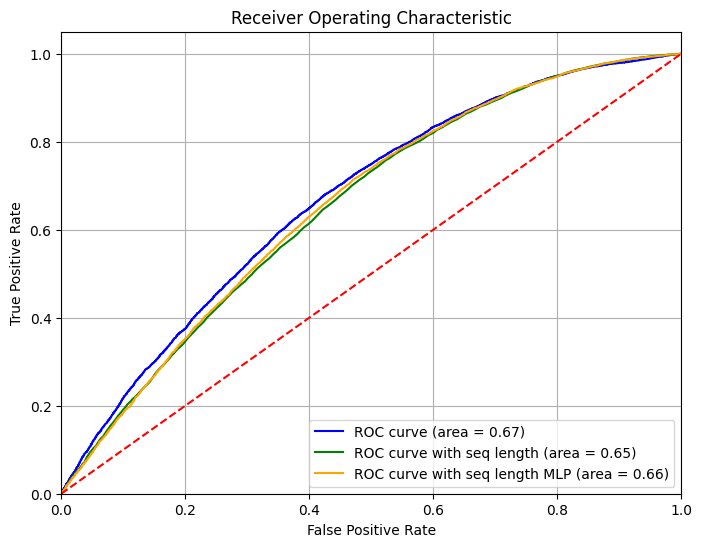

In [ ]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_test, predictions)
fpr_seq_length, tpr_seq_length, thresholds_seq_length = roc_curve(y_test, seq_length)
fpr_seq_length_mlp, tpr_seq_length_mlp, thresholds_seq_length_mlp = roc_curve(
    y_test, seq_length_predictions
)
roc_auc_seq_length = auc(fpr_seq_length, tpr_seq_length)
roc_auc = auc(fpr, tpr)
roc_auc_seq_length_mlp = auc(fpr_seq_length_mlp, tpr_seq_length_mlp)
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color="blue", label="ROC curve (area = {:.2f})".format(roc_auc))
plt.plot(
    fpr_seq_length,
    tpr_seq_length,
    color="green",
    label="ROC curve with seq length (area = {:.2f})".format(roc_auc_seq_length),
)
plt.plot(
    fpr_seq_length_mlp,
    tpr_seq_length_mlp,
    color="orange",
    label="ROC curve with seq length MLP (area = {:.2f})".format(
        roc_auc_seq_length_mlp
    ),
)
plt.title("Receiver Operating Characteristic")
plt.grid()
plt.plot([0, 1], [0, 1], color="red", linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")

In [27]:
np.corrcoef(predictions.flatten(), seq_length_predictions.flatten())

array([[1.        , 0.84341668],
       [0.84341668, 1.        ]])

In [13]:
np.corrcoef(predictions.flatten(), mppc_length)

array([[1.        , 0.77999205],
       [0.77999205, 1.        ]])

In [14]:
np.corrcoef(predictions.flatten(), pixel_length)

array([[1.        , 0.73158691],
       [0.73158691, 1.        ]])

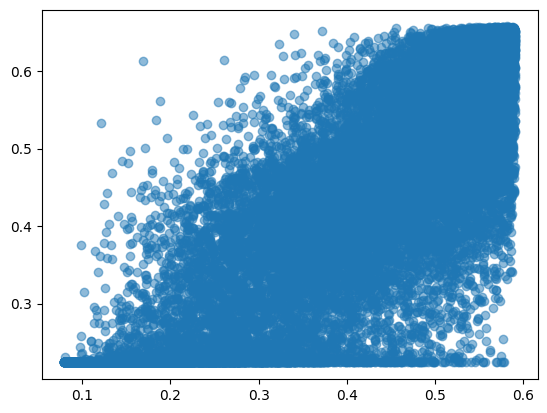

In [ ]:
plt.scatter(seq_length_predictions.flatten(), predictions.flatten(), alpha=0.5)